# Bumblebee tracking


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


CSV_PATH = "/Users/fundayildiz/Desktop/bee_results/2024-11-19_18-21-38.R13.TB.P0.6U2/data/2024-11-19_18-21-38.R13.TB.P0.6U2_id0.csv"
# ----------------------------------

df = pd.read_csv(CSV_PATH)
print("Total rows (frames):", len(df))
df.head()

Total rows (frames): 12233


,frame,ACCELERATION#pcentroid (cm/s2),ACCELERATION#wcentroid (cm/s2),ANGLE,ANGULAR_A#centroid,ANGULAR_V#centroid,AX,AY,BORDER_DISTANCE#pcentroid (cm),MIDLINE_OFFSET,...,midline_length,midline_segment_length,midline_x,midline_y,missing,normalized_midline,num_pixels,time,timestamp,visual_identification_p
0,0.0,0.00,0.00,0.62,0.00,0.00,0.00,0.00,38.48,-0.12,...,11.71,0.04,108.69,45.26,0.0,-0.12,100.0,0.00,0.0,inf
1,1.0,166.88,64.47,0.54,-833.82,-13.90,-136.76,-224.91,38.51,-0.11,...,11.03,0.04,108.65,45.19,0.0,-0.12,96.0,0.02,16666.0,inf
2,2.0,183.29,48.21,0.72,-481.77,-12.68,27.14,404.80,38.51,-0.13,...,11.04,0.04,108.61,45.25,0.0,-0.15,95.0,0.03,33333.0,inf
3,3.0,107.55,36.38,0.24,-2738.85,-34.66,245.70,-712.85,38.52,0.02,...,10.63,0.03,108.67,45.06,0.0,0.07,92.0,0.05,50000.0,inf
4,4.0,179.72,46.23,0.58,1153.64,-9.58,-205.48,838.66,38.53,-0.04,...,10.56,0.03,108.64,45.18,0.0,-0.06,92.0,0.07,66666.0,inf


## 1. How much of the bee did we actually capture?

In [2]:
# Keep only frames where the bee was really detected (missing == 0)
valid = df[df['missing'] == 0].copy().reset_index(drop=True)

pct = 100 * len(valid) / len(df)
print(f"Detected frames : {len(valid)} / {len(df)}  ({pct:.1f}%)")
print(f"Time span       : {valid['time'].min():.1f} - {valid['time'].max():.1f} s")
print(f"Body size (px)  : mean {valid['num_pixels'].mean():.0f}  (min {valid['num_pixels'].min():.0f}, max {valid['num_pixels'].max():.0f})")
print(f"X range (cm)    : {valid['X#wcentroid (cm)'].min():.1f} - {valid['X#wcentroid (cm)'].max():.1f}")
print(f"Y range (cm)    : {valid['Y#wcentroid (cm)'].min():.1f} - {valid['Y#wcentroid (cm)'].max():.1f}")

Detected frames : 319 / 12233  (2.6%)
Time span       : 0.0 - 203.9 s
Body size (px)  : mean 78  (min 16, max 150)
X range (cm)    : 20.4 - 147.1
Y range (cm)    : 30.2 - 83.3


## 2. Trajectory  (where the bee went, coloured by time)

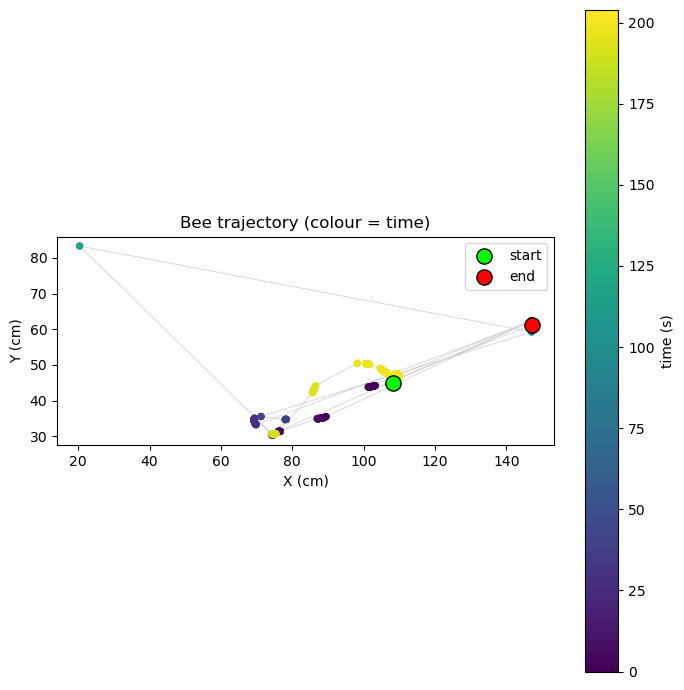

In [3]:
x = valid['X#wcentroid (cm)'].values
y = valid['Y#wcentroid (cm)'].values
t = valid['time'].values

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y, '-', color='lightgray', linewidth=0.6, zorder=1)
sc = ax.scatter(x, y, c=t, cmap='viridis', s=18, zorder=2)
ax.scatter(x[0], y[0], color='lime', s=120, edgecolor='black', label='start', zorder=3)
ax.scatter(x[-1], y[-1], color='red', s=120, edgecolor='black', label='end', zorder=3)
ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
ax.set_title('Bee trajectory (colour = time)')
ax.set_aspect('equal'); ax.legend()
plt.colorbar(sc, ax=ax, label='time (s)')
plt.tight_layout(); plt.show()

## 3. Detection over time  (when was the bee actually seen?)

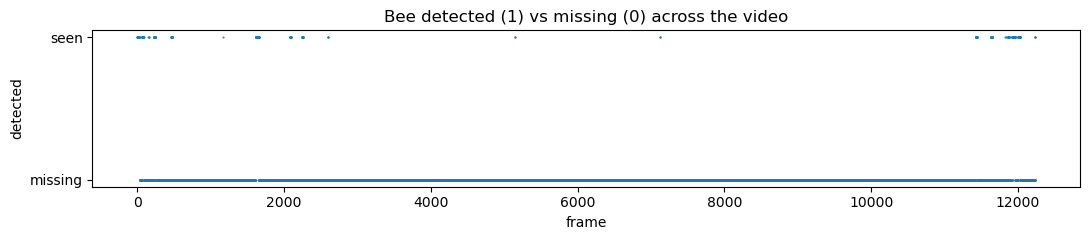

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(df['frame'], 1 - df['missing'], '.', markersize=1)
ax.set_xlabel('frame'); ax.set_ylabel('detected')
ax.set_yticks([0, 1]); ax.set_yticklabels(['missing', 'seen'])
ax.set_title('Bee detected (1) vs missing (0) across the video')
plt.tight_layout(); plt.show()

## 4. Speed over time
Computed from the X, Y positions (our own calculation, not TRex's column).
Large time gaps between detections are dropped so jumps don't inflate the speed.

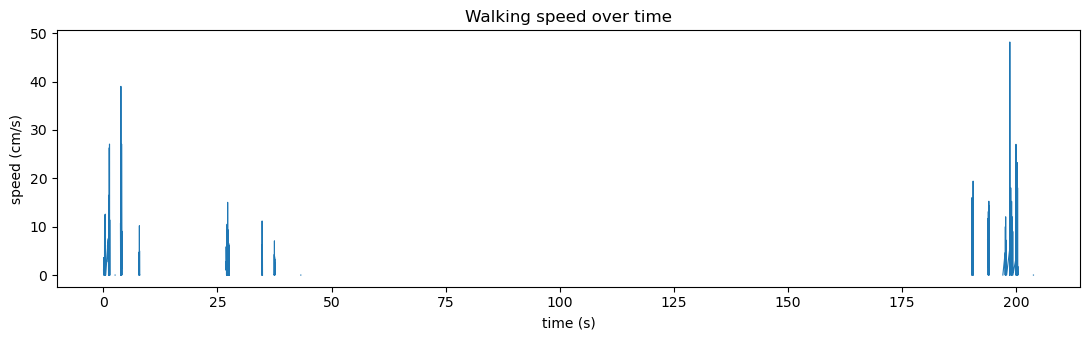

Mean speed:   4.21 cm/s
Median speed: 1.46 cm/s
Max speed:    48.17 cm/s


In [5]:
dx = np.diff(x); dy = np.diff(y); dt = np.diff(t)
dist = np.sqrt(dx**2 + dy**2)
speed = np.where(dt > 0, dist / dt, np.nan)   # cm/s
gap = dt > 1.0                                # >1 s gap = bee was lost, not real motion
speed[gap] = np.nan
t_mid = t[1:]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_mid, speed, '-', linewidth=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('speed (cm/s)')
ax.set_title('Walking speed over time')
plt.tight_layout(); plt.show()

print(f"Mean speed:   {np.nanmean(speed):.2f} cm/s")
print(f"Median speed: {np.nanmedian(speed):.2f} cm/s")
print(f"Max speed:    {np.nanmax(speed):.2f} cm/s")

## 5. Acceleration over time
Change of speed over time (cm/s²).

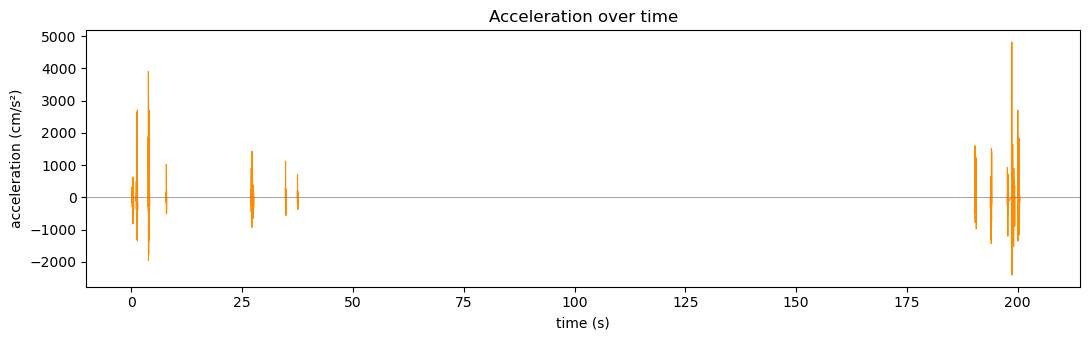

In [6]:
accel = np.diff(speed) / dt[1:]
t_acc = t_mid[1:]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_acc, accel, '-', linewidth=0.8, color='darkorange')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('time (s)'); ax.set_ylabel('acceleration (cm/s²)')
ax.set_title('Acceleration over time')
plt.tight_layout(); plt.show()